/var/folders/6v/rd9mywh12msdrg5xk2zvrs480000gn/T/ipykernel_3338/3786551802.py:40: UserWarning: Glyph 31908 (\N{CJK UNIFIED IDEOGRAPH-7CA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6v/rd9mywh12msdrg5xk2zvrs480000gn/T/ipykernel_3338/3786551802.py:40: UserWarning: Glyph 28207 (\N{CJK UNIFIED IDEOGRAPH-6E2F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/6v/rd9mywh12msdrg5xk2zvrs480000gn/T/ipykernel_3338/3786551802.py:40: UserWarning: Glyph 21675 (\N{CJK UNIFIED IDEOGRAPH-54AB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


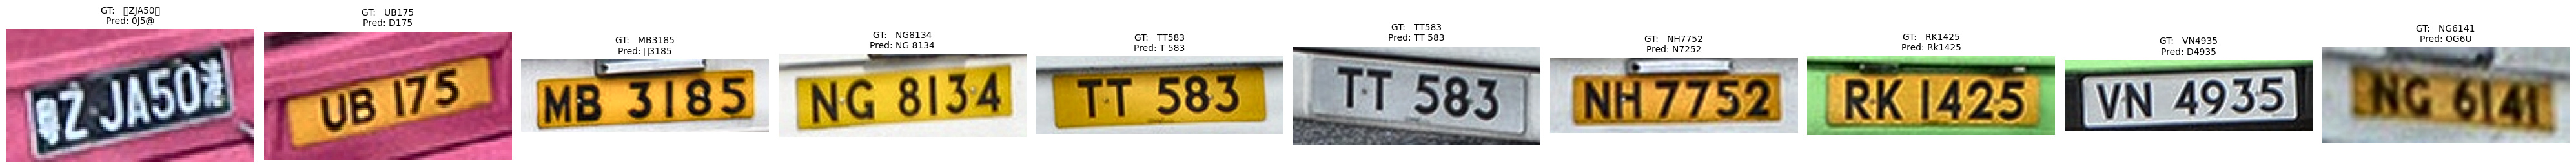

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import easyocr
from pathlib import Path
from omegaconf import OmegaConf
import cv2

max_cnt = 10
cnt = 0

fig, axes = plt.subplots(1, max_cnt, figsize=(4 * max_cnt, 4))
reader = easyocr.Reader(['ch_sim','en'], gpu=False) # this needs to run only once to load the model into memory

cfg = OmegaConf.load("../config/config.yaml")

images_path = Path(f"../{cfg.data.images_path}")
annotations_path = Path(f"../{cfg.data.annotations_path}")

samples = []
with open(annotations_path, "r", encoding="utf-8") as f:
    f.readline()
    for line in f:
        row = line.strip().split(",")
        # image_name,x1,y1,x2,y2,plate
        img_rel_path, x1, y1, x2, y2, plate_text = (
            row[0], int(row[1]), int(row[2]), int(row[3]), int(row[4]), row[5]
        )
        samples.append((img_rel_path, x1, y1, x2, y2, plate_text))
        
image_to_samples = {}
for sample in samples:
    img_name = sample[0]
    image_to_samples.setdefault(img_name, []).append(sample)

def preprocess_plate_crop(crop: np.ndarray) -> np.ndarray:
    # Увеличиваем — EasyOCR лучше работает на крупных изображениях
    h, w = crop.shape[:2]
    if h < 64:
        scale = 64 / h
        crop = cv2.resize(crop, (int(w * scale), 64), interpolation=cv2.INTER_CUBIC)

    # CLAHE — улучшаем контраст
    lab = cv2.cvtColor(crop, cv2.COLOR_BGR2LAB)
    lab[:, :, 0] = cv2.createCLAHE(2.0, (4, 4)).apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

for img_rel_path, samples_for_image in image_to_samples.items():
    img_full_path = images_path / Path(img_rel_path)
    image = cv2.imread(str(img_full_path))
    if image is None:
        continue

    h, w = image.shape[:2]

    for i, (_, x1, y1, x2, y2, plate_text) in enumerate(samples_for_image):
        pad = 4
        x1 = max(0, x1 - pad)
        y1 = max(0, y1 - pad)
        x2 = min(w, x2 + pad)
        y2 = min(h, y2 + pad)

        crop = image[y1:y2, x1:x2]
        if crop.size == 0:
            continue
        crop = preprocess_plate_crop(crop)
        if cnt >= max_cnt:
            break
        
        crop_rgb = cv2.cvtColor(crop, cv2.COLOR_BGR2RGB)
        result = reader.readtext(crop, detail=1)
        pred_text = "".join(text for _, text, _ in result)

        axes[cnt].imshow(crop_rgb)
        axes[cnt].axis("off")
        axes[cnt].set_title(f"GT:   {plate_text}\nPred: {pred_text}", fontsize=10)

        cnt += 1

plt.tight_layout()
plt.show()